## Payout Plotting

<Axes: xlabel='Date', ylabel='total_profit'>

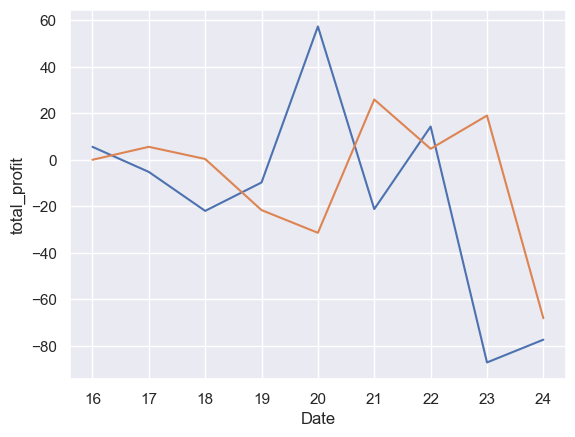

In [1]:
from bet_handle import search_db
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(search_db(False))
df['Payout'] = df['Payout'].astype(float)
df['Wager'] = df['Wager'].astype(float)
df["Date"] = pd.to_datetime(df["Date"])

daily_profit = (
    df.assign(profit=df["Payout"] - df["Wager"])
      .groupby(df["Date"].dt.day)["profit"]
      .sum()
      .reset_index(name="total_profit")
)
daily_profit["net"] = daily_profit["total_profit"].cumsum().shift(1).fillna(0)

sns.set_theme(style="darkgrid")

# Plot the responses for different events and regions
sns.lineplot(x="Date", y="total_profit",
             data=daily_profit)
sns.lineplot(x="Date", y="net",
             data=daily_profit)

In [2]:
daily_profit

,Date,total_profit,net
0,16,5.56,0.00
1,17,-5.22,5.56
2,18,-21.98,0.34
3,19,-9.76,-21.64
4,20,57.32,-31.40
5,21,-21.20,25.92
6,22,14.29,4.72
7,23,-87.14,19.01
8,24,-77.35,-68.13


## Batter and Hitter Data Plots